In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# Configure basic plot style so that plots are legible in slides/recordings.
plt.style.use("default")
plt.rcParams["figure.figsize"] = (6, 4)

In [3]:
X, y = make_classification(
    n_samples=500,       # 500 rows / observations
    n_features=4,        # 4 numeric features per observation
    n_redundant=0,       # no redundant linear combinations
    n_informative=3,     # 3 informative features, 1 mostly noise
    n_clusters_per_class=1,
    class_sep=1.2,       # controls how separable the classes are
    random_state=42      # seed for reproducibility
)

In [4]:
df = pd.DataFrame(
    X,
    columns=["age_like", "income_like", "bp_like", "chol_like"]
)

In [6]:
median_income_like = df["income_like"].median()

df["segment"] = np.where(
    df["income_like"] > median_income_like,
    "high_income",
    "low_income"
)
# Add the target labels as an integer column.
df["target"] = y

# Inspect the first few rows to get a feel for the data.
df.head()

,age_like,income_like,bp_like,chol_like,segment,target
0,0.740495,0.645216,-2.452611,0.568286,high_income,1
1,0.177306,-0.751969,-1.863758,0.162139,low_income,1
2,-0.606988,-0.826880,-1.312019,0.598459,low_income,0
3,-0.284919,-1.881849,-3.108697,0.379005,low_income,1
4,1.703563,-0.151273,-0.915554,-0.662914,low_income,1


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age_like     500 non-null    float64
 1   income_like  500 non-null    float64
 2   bp_like      500 non-null    float64
 3   chol_like    500 non-null    float64
 4   segment      500 non-null    object 
 5   target       500 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 23.6+ KB


In [8]:
df.describe(include="all")


,age_like,income_like,bp_like,chol_like,segment,target
count,500.000000,500.000000,500.000000,500.000000,500,500.000000
unique,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,high_income,NaN
freq,NaN,NaN,NaN,NaN,250,NaN
mean,0.143545,0.013216,-1.177548,1.158746,NaN,0.502000
std,1.540840,0.984809,0.942583,0.901776,NaN,0.500497
min,-4.101277,-2.940389,-4.057248,-2.251270,NaN,0.000000
25%,-1.054210,-0.641999,-1.785705,0.588029,NaN,0.000000
50%,0.283512,-0.020393,-1.153176,1.137891,NaN,1.000000
75%,1.337303,0.673899,-0.591081,1.658311,NaN,1.000000


In [9]:
df["target"].value_counts(normalize=True)


,proportion
target,
1,0.502
0,0.498


Numeric features:
    age_like, income_like, bp_like, chol_like

Categorical features:
    segment

Target:
    target

Preprocessing goals:
    • Numeric: impute missing → scale
    • Categorical: impute missing → one-hot encode


In [10]:
# Identify which columns are numeric and which are categorical.
feature_cols_num = ["age_like", "income_like", "bp_like", "chol_like"]
feature_cols_cat = ["segment"]
target_col = "target"

# X holds all features; y holds the target.
X = df[feature_cols_num + feature_cols_cat]
y = df[target_col]

X.head()

,age_like,income_like,bp_like,chol_like,segment
0,0.740495,0.645216,-2.452611,0.568286,high_income
1,0.177306,-0.751969,-1.863758,0.162139,low_income
2,-0.606988,-0.826880,-1.312019,0.598459,low_income
3,-0.284919,-1.881849,-3.108697,0.379005,low_income
4,1.703563,-0.151273,-0.915554,-0.662914,low_income


In [11]:
from sklearn.model_selection import train_test_split

# First split: separate out the test set (20%).
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,        # 20% for the final test set
    random_state=42,       # fixed seed for reproducibility
    stratify=y             # preserve class proportions
)

# Second split: from the remaining 80%, create:
#   - 60% train
#   - 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,        # 25% of 80% = 20% of full data
    random_state=42,
    stratify=y_temp
)

len(X_train), len(X_val), len(X_test)


(300, 100, 100)

Why is it a bad idea to tune k or max_depth using the test set directly?

Preprocessing Architecture

Numeric branch:
    SimpleImputer(strategy="median")
       → StandardScaler()

Categorical branch:
    SimpleImputer(strategy="most_frequent")
       → OneHotEncoder(handle_unknown="ignore")

Combined using:
    ColumnTransformer(
        ("num", numeric_transformer, numeric_columns),
        ("cat", categorical_transformer, categorical_columns)
    )

Then plugged into Pipelines with:
    • KNeighborsClassifier
    • DecisionTreeClassifier


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numeric preprocessing pipeline:
# 1. Impute missing values with column medians.
# 2. Scale each numeric feature to mean 0 and standard deviation 1.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing pipeline:
# 1. Impute missing values with the most frequent category.
# 2. One-hot encode categorical variables into binary indicator columns.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer to apply the right pipeline to each subset of columns.
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, feature_cols_num),
        ("cat", categorical_transformer, feature_cols_cat),
    ]
)

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age_like', 'income_like', 'bp_like',
                                  'chol_like']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['segment'])])

----------------------
k-Nearest Neighbors (k-NN) — Decision Rule

Given:
    Training set: (X_train, y_train)
    New point: x*
    Distance metric: d(·,·)
    Hyperparameter: k (number of neighbors)

Steps:
1. For each training example i:
       compute distance d(x*, X_train[i]).
2. Sort training examples by distance (nearest first).
3. Select the k closest examples.
4. Let those k neighbors vote for the label.
5. Predict the majority class among the k neighbors.

Notes:
• No explicit training: model = stored training data.
• Prediction cost ~ O(n_train × d_features).
• Very sensitive to feature scaling.

In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Build a complete pipeline for k-NN:
#   Step 1: preprocess with ColumnTransformer.
#   Step 2: classify with k-NN (k=5 as an initial choice).
knn_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

# Fit the pipeline on training data only.
knn_pipeline.fit(X_train, y_train)

# Predict on validation data (data not seen during fitting).
y_val_pred_knn = knn_pipeline.predict(X_val)

print("Validation performance — k-NN (k=5):")
print(classification_report(y_val, y_val_pred_knn))

# Optional: confusion matrix on validation data.
print("Confusion matrix (validation) — k-NN (k=5):")
print(confusion_matrix(y_val, y_val_pred_knn))

Validation performance — k-NN (k=5):
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        50
           1       0.94      0.94      0.94        50

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100

Confusion matrix (validation) — k-NN (k=5):
[[47  3]
 [ 3 47]]


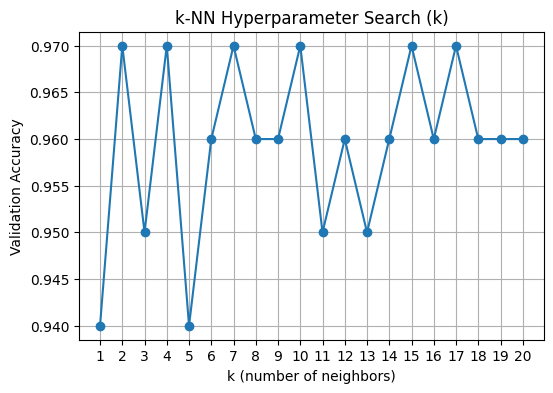

Best k according to validation accuracy: 2
Validation accuracy at best k: 0.97


In [15]:
# We will search for the best k in the range 1 to 20
ks = range(1, 21)
val_accuracies_knn = []

for k in ks:
    # For each k, we create a fresh pipeline to avoid any cross-contamination
    model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])

    # Fit on the training set
    model.fit(X_train, y_train)

    # Predict on validation set
    preds = model.predict(X_val)

    # Compute accuracy on validation set
    acc = accuracy_score(y_val, preds)
    val_accuracies_knn.append(acc)

# Plot validation accuracy as a function of k
plt.figure()
plt.plot(ks, val_accuracies_knn, marker="o")
plt.xticks(list(ks))
plt.xlabel("k (number of neighbors)")
plt.ylabel("Validation Accuracy")
plt.title("k-NN Hyperparameter Search (k)")
plt.grid(True)
plt.show()

# Identify the best k
best_k_index = int(np.argmax(val_accuracies_knn))
best_k = ks[best_k_index]
print("Best k according to validation accuracy:", best_k)
print("Validation accuracy at best k:", val_accuracies_knn[best_k_index])


In [17]:

# Combine training and validation data for final model training.
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

# Build a pipeline with the best k.
best_knn_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=best_k))
])

# Fit using the full training data (train + val).
best_knn_pipeline.fit(X_train_full, y_train_full)

# Evaluate on the held-out test set.
y_test_pred_knn = best_knn_pipeline.predict(X_test)

print("Test performance — k-NN (best k):")
print(classification_report(y_test, y_test_pred_knn))
print("Confusion matrix (test) — k-NN (best k):")
print(confusion_matrix(y_test, y_test_pred_knn))

Test performance — k-NN (best k):
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        50
           1       1.00      0.88      0.94        50

    accuracy                           0.94       100
   macro avg       0.95      0.94      0.94       100
weighted avg       0.95      0.94      0.94       100

Confusion matrix (test) — k-NN (best k):
[[50  0]
 [ 6 44]]


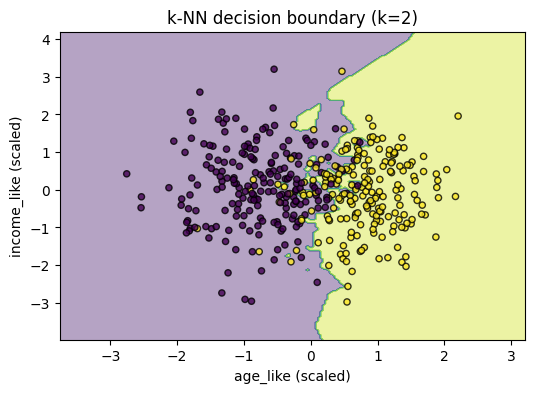

In [18]:
viz_features = ["age_like", "income_like"]

# Select only these two features and the target.
X_viz = df[viz_features]
y_viz = df["target"]

# Train/test split for visualization (separate from earlier splits for simplicity).
X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_viz, y_viz,
    test_size=0.2,
    random_state=42,
    stratify=y_viz
)

from sklearn.preprocessing import StandardScaler

# Scale the 2D features for k-NN.
scaler_v = StandardScaler()
X_train_v_s = scaler_v.fit_transform(X_train_v)
X_test_v_s  = scaler_v.transform(X_test_v)

# Train k-NN with the chosen best_k on the scaled 2D data.
knn_viz = KNeighborsClassifier(n_neighbors=best_k)
knn_viz.fit(X_train_v_s, y_train_v)

# Create a dense grid of points in 2D space.
x_min, x_max = X_train_v_s[:, 0].min() - 1, X_train_v_s[:, 0].max() + 1
y_min, y_max = X_train_v_s[:, 1].min() - 1, X_train_v_s[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Flatten grid into (N_points x 2) array.
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Predict the class for each point in the grid.
Z = knn_viz.predict(grid_points)
Z = Z.reshape(xx.shape)

# Plot decision regions + training points.
plt.figure()
plt.contourf(xx, yy, Z, alpha=0.4)  # filled contour for decision regions
plt.scatter(
    X_train_v_s[:, 0],
    X_train_v_s[:, 1],
    c=y_train_v,
    edgecolor="k",
    s=20,
    alpha=0.8
)
plt.xlabel("age_like (scaled)")
plt.ylabel("income_like (scaled)")
plt.title(f"k-NN decision boundary (k={best_k})")
plt.show()


Decision Trees — Conceptual Overview

Idea:
    Learn a tree of IF-THEN rules:

Example rules (path from root to leaf):
    IF age_like <= 0.5 AND income_like > 1.0 THEN predict class 1
    IF age_like > 0.5  AND chol_like <= -0.3 THEN predict class 0

Each internal node:
    • tests a condition on one feature, e.g. "feature_j <= threshold".

Each leaf:
    • stores a predicted class (majority class of training examples in that leaf).

Learning:
    • recursively choose splits that maximize impurity reduction.

Node Impurity for Classification

Let p_i = proportion of class i in a node.

Gini impurity:
    G = 1 − Σ p_i^2

Interpretation:
    • G = 0  → node is pure (only one class).
    • G = 0.5 (for two classes) → max impurity (50/50 mix).

Entropy:
    H = − Σ p_i log₂(p_i)

Trees choose splits that reduce impurity the most (maximize impurity reduction).

In [19]:
def gini_impurity(labels):
    """
    Compute Gini impurity for a 1D array-like of integer class labels.

    Gini impurity is defined as:
        G = 1 - sum(p_i^2)
    where p_i is the proportion of class i in the node.

    Parameters
    ----------
    labels : array-like of shape (n_samples,)
        Integer class labels (e.g., 0, 1, 2, ...).

    Returns
    -------
    float
        Gini impurity value, between 0 (pure) and at most 1 - 1/K for K classes.
    """
    labels = np.asarray(labels)

    # Edge case: if the node is empty, we define impurity as 0.
    if labels.size == 0:
        return 0.0

    # Count how many times each class appears.
    # np.bincount assumes labels are non-negative integers.
    counts = np.bincount(labels)

    # Convert counts to probabilities.
    probs = counts / labels.size

    # Gini formula.
    return 1.0 - np.sum(probs ** 2)

# Quick checks:
print("Gini([0, 0, 0])   =", gini_impurity([0, 0, 0]))    # expect 0 (pure)
print("Gini([0, 1])      =", gini_impurity([0, 1]))        # expect 0.5
print("Gini([0, 0, 1, 1])=", gini_impurity([0, 0, 1, 1]))  # expect 0.5
print("Gini([0, 0, 0, 1])=", gini_impurity([0, 0, 0, 1]))  # expect between 0 and 0.5

Gini([0, 0, 0])   = 0.0
Gini([0, 1])      = 0.5
Gini([0, 0, 1, 1])= 0.5
Gini([0, 0, 0, 1])= 0.375


In [20]:
from sklearn.tree import DecisionTreeClassifier

# Build a tree pipeline using the same preprocessor.
tree_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(
        criterion="gini",   # use Gini impurity
        max_depth=None,     # no explicit depth limit (may overfit)
        random_state=42
    ))
])

# Fit on training data.
tree_pipeline.fit(X_train, y_train)

# Predict on validation data.
y_val_pred_tree = tree_pipeline.predict(X_val)

print("Validation performance — Decision Tree (max_depth=None):")
print(classification_report(y_val, y_val_pred_tree))
print("Confusion matrix (validation) — Decision Tree:")
print(confusion_matrix(y_val, y_val_pred_tree))


Validation performance — Decision Tree (max_depth=None):
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        50
           1       0.90      0.88      0.89        50

    accuracy                           0.89       100
   macro avg       0.89      0.89      0.89       100
weighted avg       0.89      0.89      0.89       100

Confusion matrix (validation) — Decision Tree:
[[45  5]
 [ 6 44]]


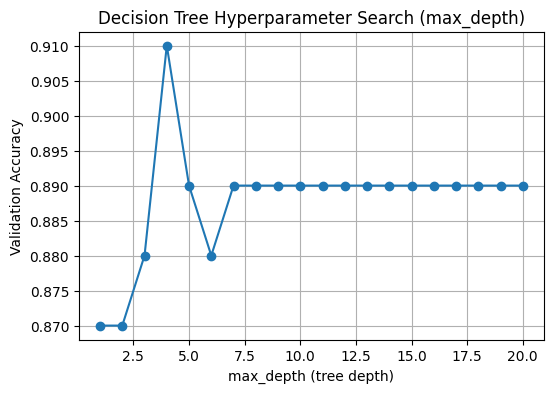

Best max_depth according to validation accuracy: 4
Validation accuracy at best depth: 0.91


In [21]:
depths = range(1, 21)  # try tree depths from 1 to 20
val_accuracies_tree = []

for d in depths:
    # Build a fresh pipeline for each depth.
    model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=d,
            criterion="gini",
            random_state=42
        ))
    ])

    # Fit on training data.
    model.fit(X_train, y_train)

    # Predict on validation data.
    preds = model.predict(X_val)

    # Compute validation accuracy.
    acc = accuracy_score(y_val, preds)
    val_accuracies_tree.append(acc)

# Plot validation accuracy vs max_depth.
plt.figure()
plt.plot(depths, val_accuracies_tree, marker="o")
plt.xlabel("max_depth (tree depth)")
plt.ylabel("Validation Accuracy")
plt.title("Decision Tree Hyperparameter Search (max_depth)")
plt.grid(True)
plt.show()

best_depth_idx = int(np.argmax(val_accuracies_tree))
best_depth = depths[best_depth_idx]
print("Best max_depth according to validation accuracy:", best_depth)
print("Validation accuracy at best depth:", val_accuracies_tree[best_depth_idx])

In [22]:
# Build pipeline with the chosen best depth.
best_tree_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=best_depth,
        criterion="gini",
        random_state=42
    ))
])

# Fit on combined train + validation data.
best_tree_pipeline.fit(X_train_full, y_train_full)

# Evaluate on test data.
y_test_pred_tree = best_tree_pipeline.predict(X_test)

print("Test performance — Decision Tree (best depth):")
print(classification_report(y_test, y_test_pred_tree))
print("Confusion matrix (test) — Decision Tree (best depth):")
print(confusion_matrix(y_test, y_test_pred_tree))

Test performance — Decision Tree (best depth):
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        50
           1       0.92      0.88      0.90        50

    accuracy                           0.90       100
   macro avg       0.90      0.90      0.90       100
weighted avg       0.90      0.90      0.90       100

Confusion matrix (test) — Decision Tree (best depth):
[[46  4]
 [ 6 44]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


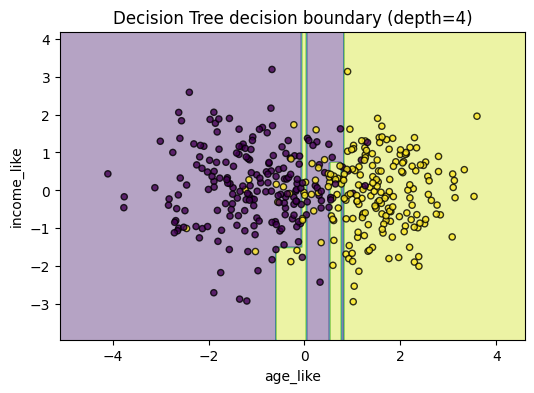

In [23]:
# Use the same two numeric features as for k-NN visualization.
viz_features = ["age_like", "income_like"]
X_viz = df[viz_features]
y_viz = df["target"]

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_viz, y_viz,
    test_size=0.2,
    random_state=42,
    stratify=y_viz
)

# Decision Trees do not require scaling, since they use thresholds on raw values.
tree_viz = DecisionTreeClassifier(
    max_depth=best_depth,
    criterion="gini",
    random_state=42
)
tree_viz.fit(X_train_v, y_train_v)

# Build grid in raw 2D feature space.
x_min, x_max = X_train_v[viz_features[0]].min() - 1, X_train_v[viz_features[0]].max() + 1
y_min, y_max = X_train_v[viz_features[1]].min() - 1, X_train_v[viz_features[1]].max() + 1

xx_raw, yy_raw = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid_raw = np.c_[xx_raw.ravel(), yy_raw.ravel()]

# Predict for each grid point.
Z_tree = tree_viz.predict(grid_raw)
Z_tree = Z_tree.reshape(xx_raw.shape)

# Plot tree decision regions and training data.
plt.figure()
plt.contourf(xx_raw, yy_raw, Z_tree, alpha=0.4)
plt.scatter(
    X_train_v[viz_features[0]],
    X_train_v[viz_features[1]],
    c=y_train_v,
    edgecolor="k",
    s=20,
    alpha=0.8
)
plt.xlabel(viz_features[0])
plt.ylabel(viz_features[1])
plt.title(f"Decision Tree decision boundary (depth={best_depth})")
plt.show()

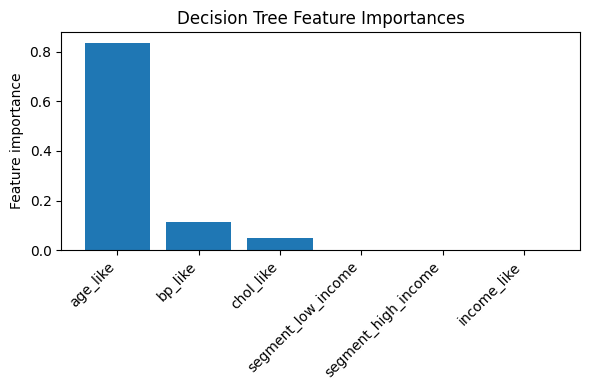

In [24]:
# Fit a tree on fully preprocessed features to extract feature importances.
X_full_processed = preprocessor.fit_transform(X_train_full)
tree_raw = DecisionTreeClassifier(
    max_depth=best_depth,
    criterion="gini",
    random_state=42
)
tree_raw.fit(X_full_processed, y_train_full)

# Extract the importance scores (one per processed feature).
importances = tree_raw.feature_importances_

# Numeric feature names (unchanged).
num_features_out = feature_cols_num

# One-hot encoded categorical feature names.
cat_encoder = preprocessor.named_transformers_["cat"]["onehot"]
cat_features_out = list(cat_encoder.get_feature_names_out(feature_cols_cat))

# Concatenate numeric and categorical output feature names.
all_feature_names = num_features_out + cat_features_out

# Sort feature indices by importance in descending order.
sorted_idx = np.argsort(importances)[::-1]

plt.figure()
plt.bar(range(len(importances)), importances[sorted_idx])
plt.xticks(
    range(len(importances)),
    [all_feature_names[i] for i in sorted_idx],
    rotation=45,
    ha="right"
)
plt.ylabel("Feature importance")
plt.title("Decision Tree Feature Importances")
plt.tight_layout()
plt.show()

Model Comparison (k-NN vs Decision Tree)

k-NN:


    * Distance-based, instance-based.
    * Very sensitive to feature scaling.
    * Hyperparameter: k (number of neighbors).
    * Decision boundaries: smooth but can be very irregular.
    * Prediction can be slow for large training sets.





Decision Tree:
  * Rule-based, axis-aligned splits.
  * No scaling required (thresholds on raw values).
  *  Hyperparameters: max_depth, min_samples_split, min_samples_leaf, etc.
  * Decision boundaries: rectangular regions; interpretable rules.
  * Fast prediction once trained.


Common Pitfalls

k-NN:
    *  Forgetting to scale numeric features.
    * Using k=1 on noisy data (overfitting).
    *  Using huge k on imbalanced data → majority-class bias.

Decision Trees:
    * Letting max_depth be too large → overfitting.
    * Ignoring class imbalance → biased splits.
    *  Very small leaves (high variance).

General:
    * Tuning hyperparameters on the test set.
    * Only looking at accuracy (ignoring precision/recall/F1).
    * Not inspecting confusion matrix or feature importance.

From DataFrame to Classifier — End-to-End Pattern

1. Load DataFrame and perform basic EDA.
2. Identify numeric vs categorical features.
3. Design preprocessing:
   • imputation
   • encoding
   • scaling
4. Split data:
   • train / validation / test
5. Build Pipelines:
   • preprocessor → k-NN
   • preprocessor → Decision Tree
6. Tune hyperparameters:
   • k for k-NN
   • max_depth for Tree
7. Evaluate on held-out test set.
8. Visualize:
   • decision boundaries (2D)
   • feature importances
9. Reflect on model behavior, bias–variance, and pitfalls.